In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel,Field
from typing import List,Annotated
import operator
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage,BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()
import os
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview",api_key=os.getenv('GEMINI_API_KEY'))



In [23]:
class JokeState(BaseModel):
    topic : str 
    joke : str | None = None
    explanation : str | None = None

In [24]:
def genrate_joke(state:JokeState):
    prompt = f"genrate the joke on topic {state.topic}"

    res = llm.invoke(prompt)

    return {'joke':res.content[0]['text']}

In [25]:
def genrate_explanation(state:JokeState):
    prompt = f"write a explanation on these joke {state.joke}"

    res = llm.invoke(prompt)
    

    return {'explanation':res.content[0]['text']}

In [26]:
graph = StateGraph(JokeState)

graph.add_node('genrate_joke',genrate_joke)
graph.add_node('genrate_explanation',genrate_explanation)


graph.add_edge(START,'genrate_joke')
graph.add_edge('genrate_joke','genrate_explanation')
graph.add_edge('genrate_explanation',END)


checkpointer = InMemorySaver()


workflow = graph.compile(checkpointer=checkpointer)



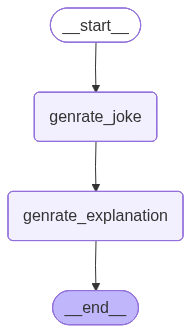

In [27]:
workflow

In [38]:
config = {'configurable':{'thread_id':'1'}}
config2 = {'configurable':{'thread_id':'2'}}
res = workflow.invoke({'topic':'china'},config=config2)

In [39]:
res

{'topic': 'china',
 'joke': 'Here are a few jokes about China, ranging from wordplay to observations:\n\n**The Observation Joke**\nIf you are a "one-in-a-million" kind of person in China... there are still about 1,400 people exactly like you.\n\n**The Puns**\n*   **Q:** Why did the man go to China to learn how to cook?\n    **A:** Because he wanted to get to the **wok** of the matter!\n*   **Q:** Why did the Great Wall of China get a promotion?\n    **A:** Because it was **outstanding** in its field for over 2,000 years.\n\n**The "Made in China" Joke**\nI bought a "Made in China" thesaurus the other day. Not only is it terrible, but it\'s also terrible.\n\n**The Panda Joke**\nA panda walks into a cafe in Beijing. He orders a bowl of noodles, eats it, pulls out a pistol, fires two shots into the air, and heads for the door.\n"Wait!" shouts the waiter. "What was that for?" \nThe panda tosses him a biology book and says, "Look me up."\nThe waiter opens the book to the panda section and re

In [35]:
list(workflow.get_state(config=config))

[{'topic': 'pakistan',
  'joke': 'Here are a few lighthearted jokes about life in Pakistan:\n\n**1. The Wedding Invitation**\nA foreign tourist is invited to a Pakistani wedding. The invitation says "Dinner at 8:00 PM." \nHe arrives exactly at 8:00 PM and finds the hall empty, except for a waiter sweeping the floor.\nHe asks the waiter, "Am I early?"\nThe waiter replies, "Sir, at 8:00 PM, the chicken is still alive. Please come back at 11:00 PM if you want to see the guests, and at 1:00 AM if you actually want to eat!"\n\n**2. The Cricket Fan**\nAn interviewer asks a Pakistani cricket fan: "Why is your team so unpredictable? One day they play like world champions, and the next day they collapse."\nThe fan sighs and says: "It’s simple. Our team doesn\'t play against the other country; they play against the fans\' blood pressure. It’s not a sport, it’s a cardio workout for 240 million people!"\n\n**3. The Power Outage (Load Shedding)**\nA man in Lahore is bragging to his friend: "My son 

In [43]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'china', 'joke': 'Here are a few jokes about China, ranging from wordplay to observations:\n\n**The Observation Joke**\nIf you are a "one-in-a-million" kind of person in China... there are still about 1,400 people exactly like you.\n\n**The Puns**\n*   **Q:** Why did the man go to China to learn how to cook?\n    **A:** Because he wanted to get to the **wok** of the matter!\n*   **Q:** Why did the Great Wall of China get a promotion?\n    **A:** Because it was **outstanding** in its field for over 2,000 years.\n\n**The "Made in China" Joke**\nI bought a "Made in China" thesaurus the other day. Not only is it terrible, but it\'s also terrible.\n\n**The Panda Joke**\nA panda walks into a cafe in Beijing. He orders a bowl of noodles, eats it, pulls out a pistol, fires two shots into the air, and heads for the door.\n"Wait!" shouts the waiter. "What was that for?" \nThe panda tosses him a biology book and says, "Look me up."\nThe waiter opens the book to the